In [2]:
############### import libraries ###############

import itertools
import joblib
import json
import os
from pathlib import Path
import random
from IPython.display import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.utils import plot_model
from keras.callbacks import EarlyStopping, Callback, ModelCheckpoint

2026-02-24 10:47:36.971525: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
############### TRAINING AND TEST DATASETS PATHS ###############

def download(url, output) :
    if not os.path.exists(output):
        print(f"{output} not found. Downloading...")
        urllib.request.urlretrieve(url, output)
    else:
        print(f"{output} already exists. Skip download.")

download("https://drive.google.com/uc?id=1JPOVfYXJNXeBgG_V0auiuK5W2CvP4_td", "training.csv")
download("https://drive.google.com/uc?id=11W8QiL98fEqV7Xfbw-xgXCC7G-SM1yMb", "test.csv")

training_path = 'training.csv'
test_path     = 'test.csv'


############### SAVE MODEL AND SUBMISSION FILE PATHS ###############

SAVE_MODEL_DIR    = Path('best_model')
model_name   = 'model.keras'
imputer_name = 'imputer.joblib'
scaler_name  = 'scaler.joblib'
meta_name    = 'meta.json'

# save plot figures
SAVE_PIC_DIR = Path('out')
model_diagram_name = 'model_diagram.png'
dnn_output_name = 'dnn_output.png'
history_name = 'history.png'

os.makedirs(SAVE_PIC_DIR, exist_ok = True)

SAVE_SUBMISSION_DIR  = Path('submission')
save_submission_name = 'submission.csv'

os.makedirs(SAVE_MODEL_DIR, exist_ok = True)

training.csv already exists. Skip download.
test.csv already exists. Skip download.


In [4]:
############### callback for AMS evaluation ###############

class AMSCallback(Callback):
    def __init__(self, X_val, y_val, w_val, w_Factor, n_thr = 201, pred_bs = 8192):
        super().__init__()
        self.X_val    = X_val
        self.y_val    = y_val
        self.w_val    = w_val
        self.w_Factor = w_Factor
        self.n_thr    = n_thr
        self.pred_bs  = pred_bs

    def ams_val(self, s, b, b_r):
        radicand = 2.0 * ((s + b + b_r) * np.log(1.0 + s / (b + b_r)) - s)
        return np.sqrt(max(radicand, 0.0))

    def search_threshold(self, pred, b_r):
        best_ams = 0.0
        best_thr = 0.0
        for thr in np.linspace(0.0, 1.0, self.n_thr):
            s = self.w_val[(self.y_val == 1) & (pred >= thr)].sum() * self.w_Factor
            b = self.w_val[(self.y_val == 0) & (pred >= thr)].sum() * self.w_Factor
            score = self.ams_val(s, b, b_r)
            if score > best_ams:
                best_ams = score
                best_thr = float(thr)
        return float(best_ams), float(best_thr)

    def on_epoch_end(self, epoch, logs = None):
        logs = logs or {}
        pred = self.model.predict(self.X_val, batch_size = self.pred_bs, verbose = 0).ravel()
        ams, thr = self.search_threshold(pred, b_r = 10.0)
        logs["val_ams"] = ams
        logs["val_thr"] = thr
        print(f"Epoch {epoch + 1}:")
        print(f"val_AMS: {ams:.3f}, best_threshold: {thr:.3f}, val_loss: {logs['val_loss']:.3f}, val_auc: {logs['val_auc']:.3f}\n")

def ams(s, b, b_r):
    radicand = 2.0 * ((s + b + b_r) * np.log(1.0 + s / (b + b_r)) - s)
    return np.sqrt(max(radicand, 0.0))

def best_ams_from_pred(pred, y_true, w_true, wFactor, b_r, n_thr):
    best     = -np.inf
    best_thr = None
    for thr in np.linspace(0.0, 1.0, n_thr):
        s = w_true[(pred > thr) & (y_true == 1)].sum()
        b = w_true[(pred > thr) & (y_true == 0)].sum()
        score = ams(s * wFactor, b * wFactor, b_r = b_r)
        if score > best:
            best     = score
            best_thr = float(thr)
    return float(best), float(best_thr)

In [5]:
############### constants ###############

dp              = 0.3    # dropout
lr              = 5e-4   # learning_rate
wd              = 1e-5   # weight_decay
bs              = 1024   # model.fitのbatch_size
n_thr           = 501    # thresholdの評価数 初めは粗く設定
n_thr_eval      = 10001  # 最後はより細かく評価
n_thr_test_eval = 20001  # test setの評価数
base_units      = 256

important_idx = [2, 13, 1, 0, 7, 10, 5, 19, 23, 24, 16, 21, 11, 22, 3]  # 重要な特徴量(ただし、weight, Label, EventIdは除く)

In [6]:
############### load training data ###############

df = pd.read_csv(training_path)

y = (df["Label"] == "s").astype(int).values

w = df["Weight"].values

X = df.drop(columns=["EventId", "Weight", "Label"]).values

d = X.shape[1]

# 重要なカラムの欠損フラグを追加
X = np.where(X == -999.0, np.nan, X)
X = np.concatenate([X, np.isnan(X[:, important_idx]).astype(np.float32)], axis=1)

Epoch 1:
val_AMS: 1.797, best_threshold: 0.002, val_loss: 0.018, val_auc: 0.667

Epoch 2:
val_AMS: 2.222, best_threshold: 0.006, val_loss: 0.017, val_auc: 0.710

Epoch 3:
val_AMS: 2.478, best_threshold: 0.010, val_loss: 0.017, val_auc: 0.734

Epoch 4:
val_AMS: 2.705, best_threshold: 0.012, val_loss: 0.016, val_auc: 0.750

Epoch 5:
val_AMS: 2.880, best_threshold: 0.016, val_loss: 0.016, val_auc: 0.762

Epoch 6:
val_AMS: 3.000, best_threshold: 0.022, val_loss: 0.016, val_auc: 0.772

Epoch 7:
val_AMS: 3.118, best_threshold: 0.018, val_loss: 0.016, val_auc: 0.779

Epoch 8:
val_AMS: 3.192, best_threshold: 0.024, val_loss: 0.016, val_auc: 0.788

Epoch 9:
val_AMS: 3.287, best_threshold: 0.022, val_loss: 0.016, val_auc: 0.795

Epoch 10:
val_AMS: 3.343, best_threshold: 0.024, val_loss: 0.016, val_auc: 0.799

Epoch 11:
val_AMS: 3.367, best_threshold: 0.026, val_loss: 0.015, val_auc: 0.801

Epoch 12:
val_AMS: 3.446, best_threshold: 0.030, val_loss: 0.015, val_auc: 0.807

Epoch 13:
val_AMS: 3.473,

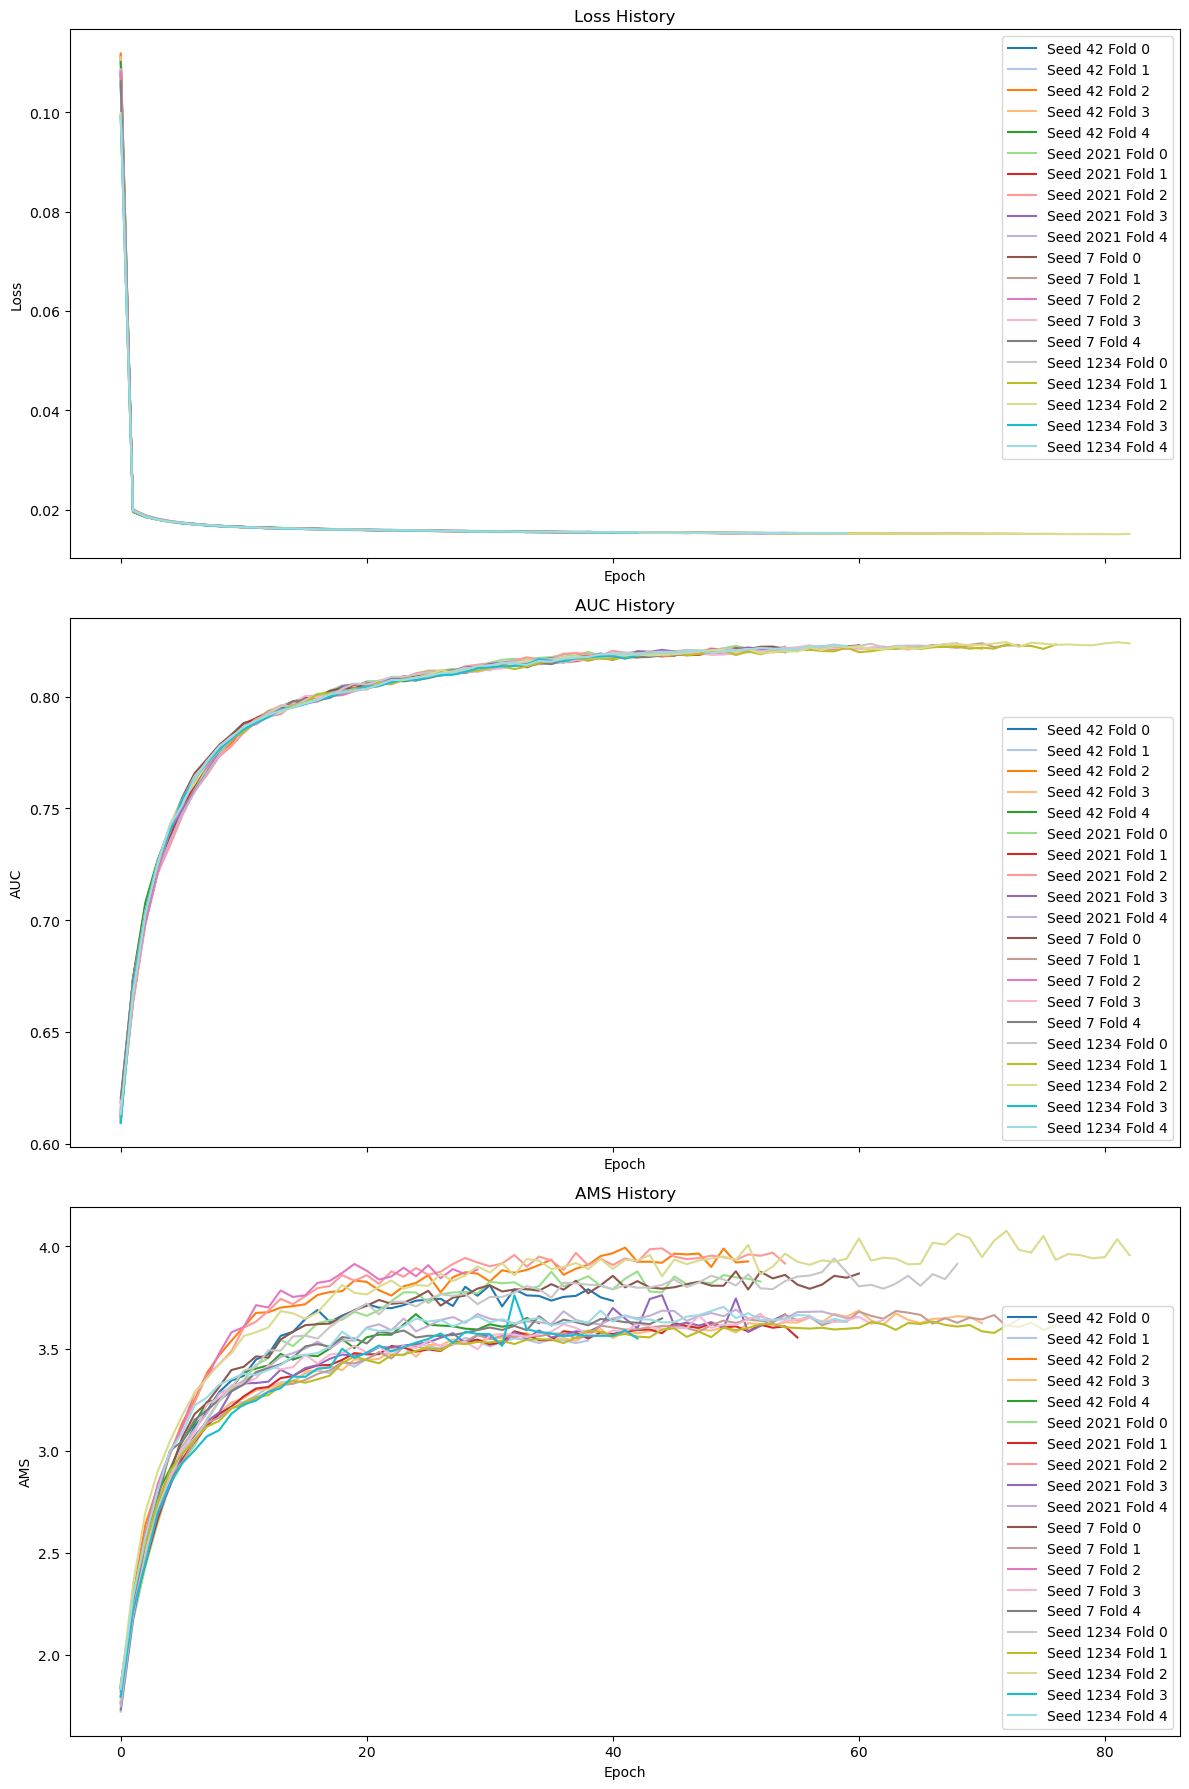

<Figure size 640x480 with 0 Axes>

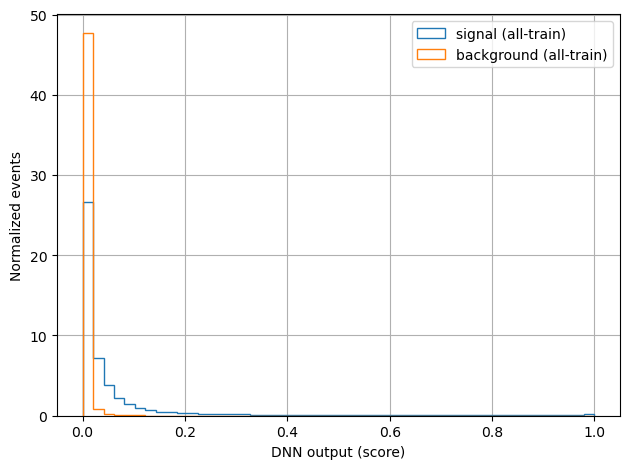

<Figure size 640x480 with 0 Axes>

In [7]:
############### training and evaluation ###############

# K-fold setting
K = 5
skf = StratifiedKFold(n_splits = K, shuffle = True, random_state = 42)

# seed
seeds = [42, 2021, 7, 1234]

# OOF
oof_seed = {}
ams10_seed = {}

cmap = plt.get_cmap('tab20')

colors = [[cmap(i) for i in range(j * K, (j + 1) * K)] for j in range(len(seeds))]
fig, axes = plt.subplots(3, 1, figsize = (12, 18), sharex = True)
plt.tight_layout()

############### OOF and K-fold training ###############

for i, seed in enumerate(seeds):
    oof_pred = np.zeros(len(X), dtype = np.float32)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        np.random.seed(seed)
        random.seed(seed)
        tf.random.set_seed(seed)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        w_train, w_val = w[train_idx], w[val_idx]

        imputer = SimpleImputer(strategy = "median")
        X_train = imputer.fit_transform(X_train)
        X_val   = imputer.transform(X_val)

        scaler = StandardScaler()
        # 数値特徴だけ標準化
        X_train_scaled = scaler.fit_transform(X_train[:, :d])
        X_val_scaled   = scaler.transform(X_val[:, :d])

        # 再結合
        X_train = np.concatenate([X_train_scaled, X_train[:, d:]], axis=1)
        X_val   = np.concatenate([X_val_scaled, X_val[:, d:]], axis = 1)

        input_dim = X_train.shape[1]

        wFactor = w.sum() / w_val.sum()

        ############### MODELING ###############

        model = keras.Sequential([
            layers.Input(shape = (input_dim,)),
            layers.Dense(base_units, activation = "gelu"),
            layers.Dropout(dp),
            layers.Dense(base_units // 2, activation = "gelu"),
            layers.Dropout(dp),
            layers.Dense(base_units // 4, activation = "gelu"),
            layers.Dropout(dp),
            layers.Dense(1, activation = "sigmoid")
        ])

        opt = keras.optimizers.AdamW(
            learning_rate = lr,
            weight_decay = wd
        )

        model.compile(
            optimizer = opt,
            loss = "binary_crossentropy",
            metrics = [keras.metrics.AUC(name="auc")]
        )

        # if (i == 0 and fold == 0):
        #     model.summary()
        #     plot_model(
        #         model,
        #         to_file = SAVE_PIC_DIR / f"{model_diagram_name}",
        #         show_shapes = True,
        #         show_layer_names = True
        #     )
        #     Image(filename = SAVE_PIC_DIR / f"{model_diagram_name}")

        ams_cb = AMSCallback(X_val, y_val, w_val, wFactor, n_thr = n_thr, pred_bs = 8192)

        earlystopping = EarlyStopping(
            monitor              = "val_ams",
            mode                 = "max",
            patience             = 10,
            restore_best_weights = True
        )

        model_path = SAVE_MODEL_DIR / f"seed_{seed}" / f"fold_{fold}" / f"{model_name}"

        # modelcheckpoint = ModelCheckpoint(
        #     str(model_path),
        #     monitor        = "val_ams",
        #     mode           = "max",
        #     save_best_only = True,
        #     verbose        = 0
        # )

        history = model.fit(
            X_train, y_train,
            sample_weight   = w_train,
            validation_data = (X_val, y_val, w_val),
            epochs          = 1000,
            batch_size      = bs,
            verbose         = 0,
            callbacks       = [ams_cb, earlystopping]
            # callbacks       = [ams_cb, earlystopping, modelcheckpoint]
        )

        ############### Save the best model ###############

        # joblib.dump(imputer,  SAVE_MODEL_DIR / f"seed_{seed}" / f"fold_{fold}" / f"{imputer_name}")
        # joblib.dump(scaler, SAVE_MODEL_DIR / f"seed_{seed}" / f"fold_{fold}" / f"{scaler_name}")

        val_pred = model.predict(X_val, batch_size = 8192, verbose = 0).ravel()
        oof_pred[val_idx] = val_pred

        loss_history = history.history["loss"]
        auc_history  = history.history["auc"]
        ams_history  = history.history["val_ams"]
        axes[0].plot(loss_history, label = f"Seed {seed} Fold {fold}", color = colors[i][fold])
        axes[1].plot(auc_history,  label = f"Seed {seed} Fold {fold}", color = colors[i][fold])
        axes[2].plot(ams_history,  label = f"Seed {seed} Fold {fold}", color = colors[i][fold])

        best_ams_fold_10, best_thr_fold_10 = best_ams_from_pred(val_pred, y_val, w_val, wFactor, b_r = 10.0, n_thr = n_thr_eval)
        best_ams_fold_30, best_thr_fold_30 = best_ams_from_pred(val_pred, y_val, w_val, wFactor, b_r = 30.0, n_thr = n_thr_eval)

        print(f"======== Result on validation set for seed: {seed} Fold: {fold} ========")
        print(f"val_loss: {history.history['val_loss'][-1]:3.3f}, val_auc: {history.history['val_auc'][-1]:3.3f}")
        print("b_r=10.0:")
        print(f"AMS: {best_ams_fold_10:.5f}, at threshold: {best_thr_fold_10:.5f}")
        print("b_r=30.0:")
        print(f"AMS: {best_ams_fold_30:.5f}, at threshold: {best_thr_fold_30:.5f}")
        print("\n")


    ############### EVALUATION OF VALIDATION DATASETS ###############

    best_ams_10, best_thr_10 = best_ams_from_pred(oof_pred, y, w, wFactor = 1, b_r = 10.0, n_thr = n_thr_eval)
    best_ams_30, best_thr_30 = best_ams_from_pred(oof_pred, y, w, wFactor = 1, b_r = 30.0, n_thr = n_thr_eval)
    print(f"======== Result on validation set for seed: {seed} ========")
    print("b_r=10.0:")
    print(f"AMS: {best_ams_10:.5f}, at threshold: {best_thr_10:.5f}")
    print("b_r=30.0:")
    print(f"AMS: {best_ams_30:.5f}, at threshold: {best_thr_30:.5f}")
    print("\n")

    oof_seed[i] = oof_pred
    ams10_seed[i] = best_ams_10

#### average results ####

oof_stack = np.stack([oof_seed[i] for i in range(len(oof_seed))], axis = 0)
oof_ave = oof_stack.mean(axis = 0)

best_ams_10, best_thr_10 = best_ams_from_pred(oof_ave, y, w, wFactor = 1, b_r = 10.0, n_thr = n_thr_eval)
best_ams_30, best_thr_30 = best_ams_from_pred(oof_ave, y, w, wFactor = 1, b_r = 30.0, n_thr = n_thr_eval)

print(f"======== Result average model ========")
print("b_r=10.0:")
print(f"AMS: {best_ams_10:.5f}, at threshold: {best_thr_10:.5f}")
print("b_r=30.0:")
print(f"AMS: {best_ams_30:.5f}, at threshold: {best_thr_30:.5f}")
print("\n")

############ save meta information #############

# meta = {
#     "d": int(d),
#     "important_idx": list(map(int, important_idx)),
#     "seeds": seeds,
#     "K": K,
#     "threshold": best_thr_10,
#     "ams": best_ams_10,
# }
# with open(SAVE_MODEL_DIR / f"{meta_name}", "w") as f:
#     json.dump(meta, f)

#### plot Loss, AUC, and AMS History ####

axes[0].legend()
axes[1].legend()
axes[2].legend()
axes[0].set_xlabel("Epoch")
axes[1].set_xlabel("Epoch")
axes[2].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_ylabel("AUC")
axes[2].set_ylabel("AMS")
axes[0].set_title("Loss History")
axes[1].set_title("AUC History")
axes[2].set_title("AMS History")
plt.tight_layout()
plt.show()
plt.savefig(SAVE_PIC_DIR / f"{history_name}")

#### plot histogram of DNN output for signal and background in training dataset ####

bins = np.linspace(0.0, 1.0, 50)
plt.figure()
plt.hist(
    oof_ave[y == 1],
    bins     = bins,
    histtype = "step",
    density  = True,
    label    = "signal (all-train)",
)
plt.hist(
    oof_ave[y == 0],
    bins     = bins,
    histtype = "step",
    density  = True,
    label    = "background (all-train)",
)
plt.xlabel("DNN output (score)")
plt.ylabel("Normalized events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig(SAVE_PIC_DIR / f"{dnn_output_name}")

In [8]:
############### EVALUATION OF TEST DATASET ###############

# Load the test dataset and meta information
# df_test = pd.read_csv(test_path)
df_test = pd.read_csv(training_path)
with open(SAVE_MODEL_DIR / f"{meta_name}", "r") as f:
    meta = json.load(f)

important_idx = meta["important_idx"]
d = meta["d"]

# check if the test dataset has the "Label" and "Weight" column
has_test_label = "Label" in df_test.columns
has_test_weight = "Weight" in df_test.columns

y_test, w_test = None, None

if has_test_label and has_test_weight:
    y_test = (df_test["Label"] == "s").astype(int).values
    w_test = df_test["Weight"].values

X_test = df_test.drop(columns=["EventId", "Weight", "Label"], errors = "ignore").values

X_test = np.where(X_test == -999.0, np.nan, X_test)
X_test = np.concatenate([X_test, np.isnan(X_test[:, important_idx]).astype(np.float32)], axis = 1)

# ===== test 評価（Label と Weight がある場合のみ） =====
if has_test_label and has_test_weight:
    ######### モデルの予測を平均して test_pred を作成 #########
    test_pred_each_list = [] # それぞれの test dataset の予測値の配列
    for seed in range(len(seeds)):
        for fold in range(K):
            model   = keras.models.load_model(SAVE_MODEL_DIR / f"seed_{seeds[seed]}/fold_{fold}/{model_name}") # 学習したデータの model の読み込み
            imputer = joblib.load(SAVE_MODEL_DIR / f"seed_{seeds[seed]}/fold_{fold}/{imputer_name}")          # 学習したデータの imputer の読み込み
            scaler  = joblib.load(SAVE_MODEL_DIR / f"seed_{seeds[seed]}/fold_{fold}/{scaler_name}")           # 学習したデータの scaler の読み込み

            X_test_imp = imputer.transform(X_test)
            X_test_scaled = scaler.transform(X_test_imp[:, :d])
            X_test_reconstructed = np.concatenate([X_test_scaled, X_test_imp[:, d:]], axis = 1)

            test_pred_each = model.predict(X_test_reconstructed, batch_size = 8192, verbose = 0).ravel() # それぞれの seed, fold における test dataset の予測値
            test_pred_each_list.append(test_pred_each)

            best_ams_test_10_each, best_thr_test_10_each = best_ams_from_pred(test_pred_each, y_test, w_test, wFactor = 1.0, b_r = 10.0, n_thr = n_thr_test_eval)
            best_ams_test_30_each, best_thr_test_30_each = best_ams_from_pred(test_pred_each, y_test, w_test, wFactor = 1.0, b_r = 30.0, n_thr = n_thr_test_eval)

            print(f"########### Prediction for test dataset with seed {seeds[seed]} fold {fold} ###########")
            print(f"AMS: {best_ams_test_10_each:.5f} at threshold: {best_thr_test_10_each:.5f}\n")
    
    ######### AMS evaluation on test dataset #########

    test_pred = np.mean(np.stack(test_pred_each_list, axis = 0), axis = 0)
    best_ams_test_10, best_thr_test_10 = best_ams_from_pred(test_pred, y_test, w_test, wFactor = 1.0, b_r = 10.0, n_thr = n_thr_test_eval)
    best_ams_test_30, best_thr_test_30 = best_ams_from_pred(test_pred, y_test, w_test, wFactor = 1.0, b_r = 30.0, n_thr = n_thr_test_eval)
    print(f"########### Final AMS Result ###########")
    print("for b_r=10.0:")
    print(f"Best AMS: {best_ams_test_10:.5f} at threshold: {best_thr_test_10:.5f}\n")
    print("for b_r=30.0:")
    print(f"Best AMS: {best_ams_test_30:.5f} at threshold: {best_thr_test_30:.5f}")
elif has_test_label and not has_test_weight:
    print("test.csv に Weight カラムが無いので、test AMS の評価はスキップします。")
elif not has_test_label and has_test_weight:
    print("test.csv に Label カラムが無いので、test AMS の評価はスキップします。")
else:
    print("test.csv に Label, Weight カラムが無いので、test AMS の評価はスキップします。")

########### Prediction for test dataset with seed 42 fold 0 ###########
AMS: 3.72463 at threshold: 0.03325

########### Prediction for test dataset with seed 42 fold 1 ###########
AMS: 3.71059 at threshold: 0.03040

########### Prediction for test dataset with seed 42 fold 2 ###########
AMS: 3.77194 at threshold: 0.02410

########### Prediction for test dataset with seed 42 fold 3 ###########
AMS: 3.91682 at threshold: 0.05840

########### Prediction for test dataset with seed 42 fold 4 ###########
AMS: 3.70687 at threshold: 0.02605

########### Prediction for test dataset with seed 2021 fold 0 ###########
AMS: 3.77937 at threshold: 0.03025

########### Prediction for test dataset with seed 2021 fold 1 ###########
AMS: 3.81504 at threshold: 0.04415

########### Prediction for test dataset with seed 2021 fold 2 ###########
AMS: 3.82317 at threshold: 0.02780

########### Prediction for test dataset with seed 2021 fold 3 ###########
AMS: 3.81278 at threshold: 0.03460

########### Predicti

In [ ]:
################# submission file generation for kaggle Higgs Boson Machine Learning Challenge #########

df_test = pd.read_csv(test_path)

with open(SAVE_MODEL_DIR / f"{meta_name}", "r") as f:
    meta = json.load(f)

important_idx = meta["important_idx"]
d = meta["d"]

X_test = df_test.drop(columns=["EventId", "Weight", "Label"], errors = "ignore").values

X_test = np.where(X_test == -999.0, np.nan, X_test)
X_test = np.concatenate([X_test, np.isnan(X_test[:, important_idx]).astype(np.float32)], axis = 1)

test_pred_each_list = [] # それぞれの test dataset の予測値の配列
for seed in range(len(seeds)):
    for fold in range(K):
        model   = keras.models.load_model(SAVE_MODEL_DIR / f"seed_{seeds[seed]}/fold_{fold}/{model_name}") # 学習したデータの model の読み込み
        imputer = joblib.load(SAVE_MODEL_DIR / f"seed_{seeds[seed]}/fold_{fold}/{imputer_name}")          # 学習したデータの imputer の読み込み
        scaler  = joblib.load(SAVE_MODEL_DIR / f"seed_{seeds[seed]}/fold_{fold}/{scaler_name}")           # 学習したデータの scaler の読み込み

        X_test_imp = imputer.transform(X_test)
        X_test_scaled = scaler.transform(X_test_imp[:, :d])
        X_test_reconstructed = np.concatenate([X_test_scaled, X_test_imp[:, d:]], axis = 1)

        test_pred_each = model.predict(X_test_reconstructed, batch_size = 8192, verbose = 0).ravel() # それぞれの seed, fold における test dataset の予測値
        test_pred_each_list.append(test_pred_each)

test_pred = np.mean(np.stack(test_pred_each_list, axis = 0), axis = 0)

rank_order = test_pred.argsort().argsort() + 1

pred_class = np.where(test_pred > best_thr_10, "s", "b")

submission = pd.DataFrame({
    "EventId": df_test["EventId"].values,
    "RankOrder": rank_order.astype(int),
    "Class": pred_class
})

# if submission directory doesn't exist, make the directory and save submission file for kaggle Higgs Boson Machine Learning Challenge
os.makedirs(SAVE_SUBMISSION_DIR, exist_ok = True)
submission.to_csv(SAVE_SUBMISSION_DIR / f"{save_submission_name}", index = False)
print(f"Saved: {SAVE_SUBMISSION_DIR}/{save_submission_name}")
print(submission.head())

Saved: submission / submission.csv
   EventId  RankOrder Class
0   350000      10993     b
1   350001     157195     b
2   350002     361991     b
3   350003     465242     b
4   350004     132068     b
